# Forecasting International Student Mobility

**Group 26:** Adriano Machado, Francisco da Ana, João Lopes, Tiago Teixeira

ESN Porto is a non-profit that supports international exchange students in Porto. Students who buy a membership card get discounts at local businesses, invitations to social events, and access to cultural activities.

We analyzed five years of membership data to identify trends and forecast **weekly** sign-ups. Better predictions mean ESN Porto can staff appropriately, having enough volunteers ready when students need help most, and schedule events when demand is highest.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import os

# Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet

# Validation & Selection
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import RFECV
import optuna
import warnings
from matplotlib.gridspec import GridSpec

In [2]:
DATA_DIR = Path('data')
FIGURES_DIR = Path('figures')
RESULTS_DIR = Path('results')
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Configuration: Set to True to run hyperparameter tuning, False to load from saved results
RUN_HYPERPARAMETER_TUNING = True

In [3]:
data_dir = Path('data')

with open(data_dir / 'eventupp_students_private.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df['registerDate_dt'] = pd.to_datetime(df['registerDate'], unit='ms')
df = df.sort_values('registerDate_dt')

print(f"Total students: {len(df):,}")
print(f"Academic years: {sorted(df['academic_year'].unique())}")
print(f"Date range: {df['registerDate_dt'].min()} to {df['registerDate_dt'].max()}")


Total students: 14,168
Academic years: ['2021_2022', '2022_2023', '2023_2024', '2024_2025', '2025_2026']
Date range: 2021-08-03 12:10:42.923000 to 2025-12-02 14:34:00.471000


In [4]:
df.head(2)

,gender,birthdate,country,organization,university,registerDate,program,programDuration,academic_year,registerDate_dt
0,female,980347260000,Poland,5f1ebfbc2fd6333295e8e9af,Universidade do Porto (UP) - Faculdade de Letr...,1627992642923,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022,2021-08-03 12:10:42.923
1,female,895764420000,Germany,5f1ebfbc2fd6333295e8e9af,Instituto Politécnico do Porto - Instituto Sup...,1627992763121,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022,2021-08-03 12:12:43.121


The dataset contains 9 variables describing each membership registration, which can be categorized as follows:

- Temporal: Registration Date (Timestamp).
- Demographic: Age (derived from birthdate), Gender, and Country of origin.
- Academic: University (e.g., U.Porto, IPP), Program Type (Erasmus, Exchange, Volunteer), and Program Duration.

The data was collected between September 2021 and December 2025

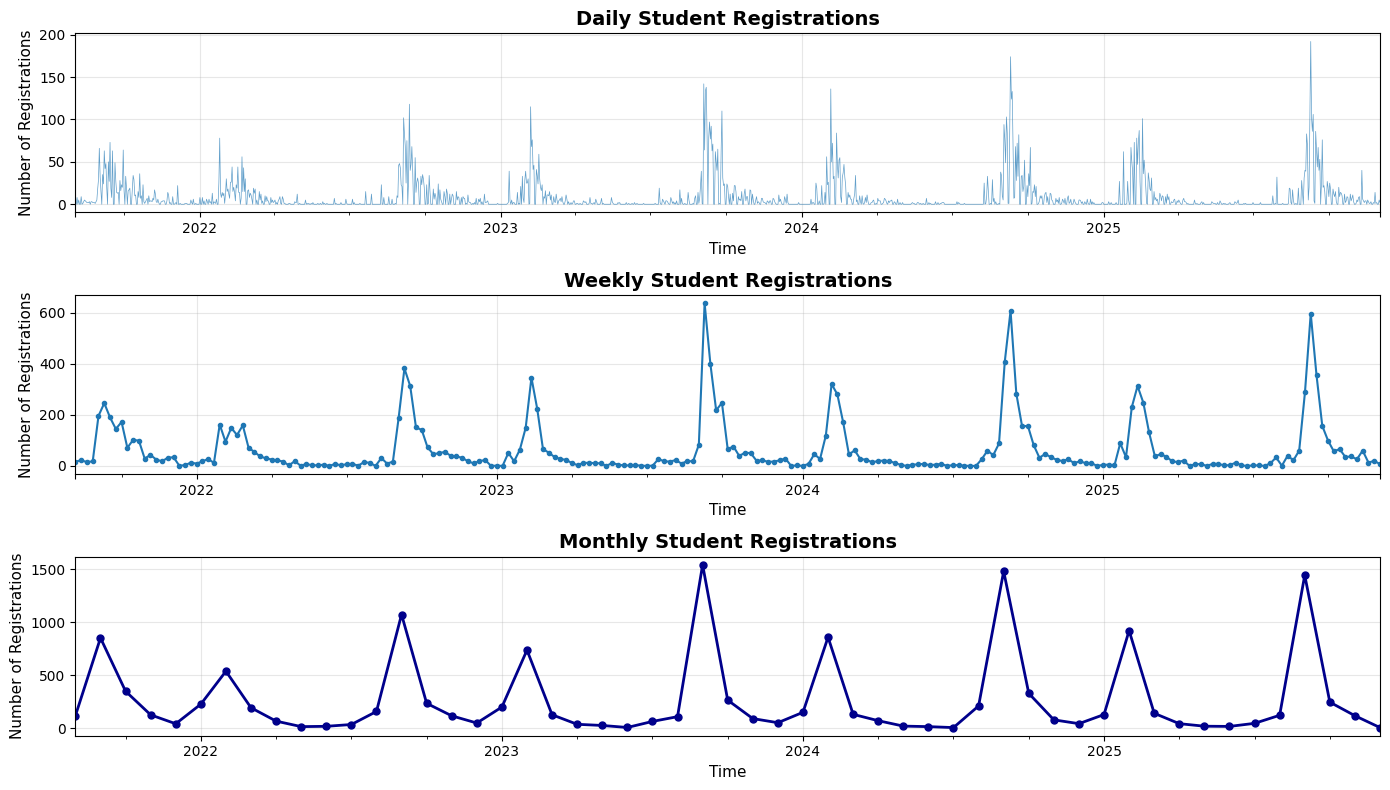

In [5]:
daily_counts = df.groupby(df['registerDate_dt'].dt.date).size()
daily_ts = pd.Series(daily_counts.values, index=pd.to_datetime(daily_counts.index))
daily_ts = daily_ts.asfreq('D', fill_value=0)  

weekly_ts = daily_ts.resample('W').sum()

monthly_ts = daily_ts.resample('ME').sum()

fig = plt.figure(figsize=(14, 8))

# Plot 1: Daily registrations
ax1 = plt.subplot(3, 1, 1)
daily_ts.plot(ax=ax1, linewidth=0.5, alpha=0.7)
ax1.set_title('Daily Student Registrations', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time', fontsize=11)
ax1.set_ylabel('Number of Registrations', fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Weekly registrations
ax2 = plt.subplot(3, 1, 2)
weekly_ts.plot(ax=ax2, linewidth=1.5, marker='o', markersize=3)
ax2.set_title('Weekly Student Registrations', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time', fontsize=11)
ax2.set_ylabel('Number of Registrations', fontsize=11)
ax2.grid(True, alpha=0.3)

# Plot 3: Monthly registrations
ax3 = plt.subplot(3, 1, 3)
monthly_ts.plot(ax=ax3, linewidth=2, marker='o', markersize=5, color='darkblue')
ax3.set_title('Monthly Student Registrations', fontsize=14, fontweight='bold')
ax3.set_xlabel('Time', fontsize=11)
ax3.set_ylabel('Number of Registrations', fontsize=11)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()


Since the raw data is recorded as timestamps, we have the flexibility to aggregate the time series at any resolution.
- Daily frequency is very noisy, with most days recording zero registrations interrupted by extreme spikes during
semester starts. 

- Monthly aggregation provided the cleanest seasonal signal but
sacrificed temporal detail. 

We choose **weekly frequency** as a balance between noise reduction and temporal resolution.

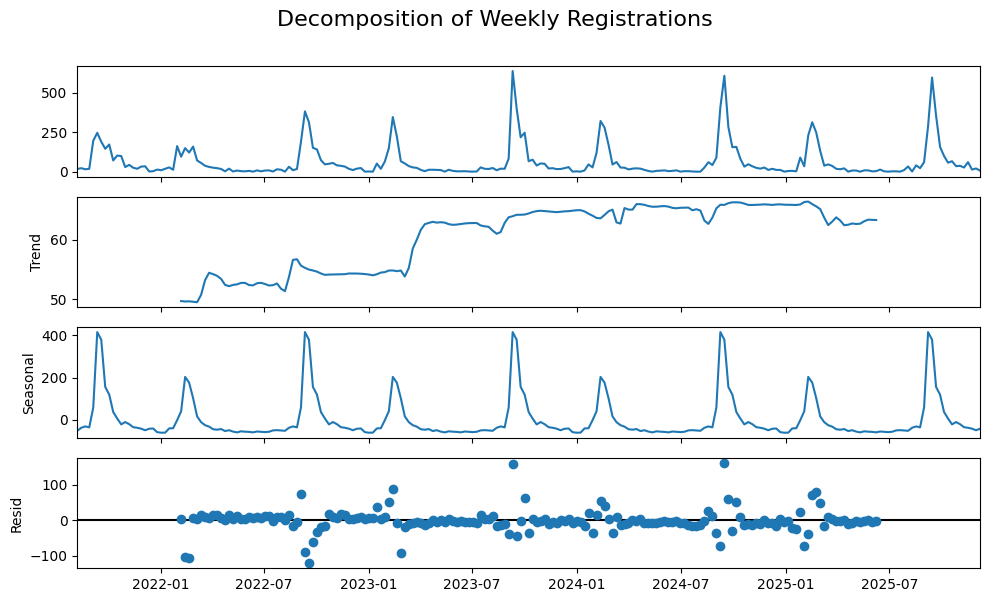

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Decompose the series (Additive model assumed initially)
# period=52 for weekly data with annual cycle
decomposition = seasonal_decompose(weekly_ts, model='additive', period=52)

fig = decomposition.plot()
fig.set_size_inches(10, 6)
plt.suptitle('Decomposition of Weekly Registrations', fontsize=16, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

* **Trend:** Recovering from the pandemic, registrations increased until mid-2023, after which the trend plateaued.
* **Seasonality:** The data has a bi-annual cycle with primary peaks in September and secondary peaks in February, corresponding to the start of academic semesters. 
* **Residuals:** For the most part, residuals hover around zero, indicating the seasonal+trend model explains the movements well. However, there are occasional positive outliers particularly around february and august (between semesters)


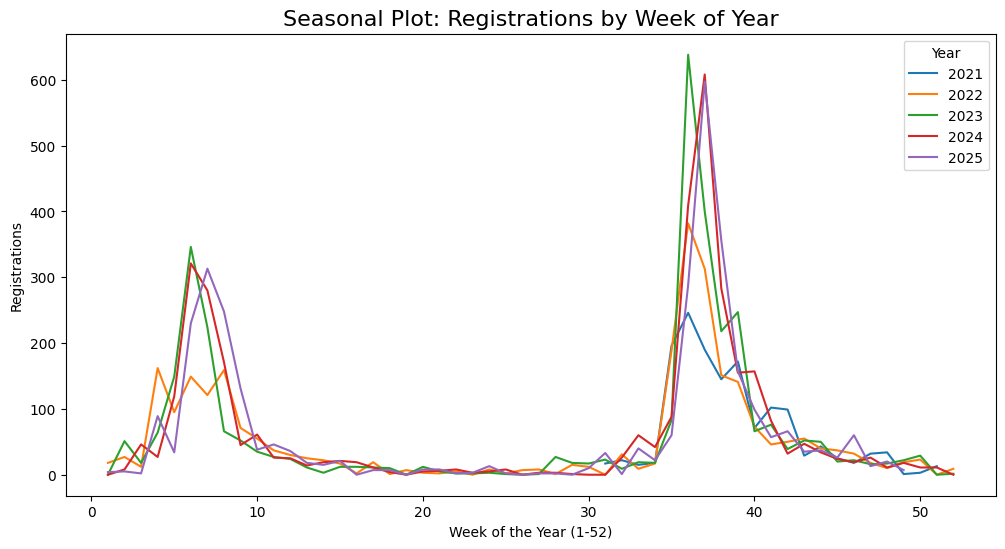

In [7]:
# Prepare data for seasonal plot
df['date'] = pd.to_datetime(df['registerDate'], unit='ms')
weekly_ts = df.set_index('date').resample('W').size()
df_seasonal = pd.DataFrame({'counts': weekly_ts})
df_seasonal['week'] = df_seasonal.index.isocalendar().week
df_seasonal['year'] = df_seasonal.index.year

# Plot overlapping years
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_seasonal, x='week', y='counts', hue='year', palette='tab10')
plt.title('Seasonal Plot: Registrations by Week of Year', fontsize=16)
plt.xlabel('Week of the Year (1-52)')
plt.ylabel('Registrations')
plt.legend(title='Year')
plt.show()

As we can see in seasonal plot there's a clear pattern in student registrations, especially in the last years (2023/2024/2025) after the recovery from the pandemic.

In [8]:
weekly_ts.head()

date
2021-08-08     17
2021-08-15     22
2021-08-22     15
2021-08-29     18
2021-09-05    196
Freq: W-SUN, dtype: int64

In [9]:
# Convert registerDate to datetime (it's in milliseconds)
df['registerDate'] = pd.to_datetime(df['registerDate'], unit='ms')

# Set as index
df.set_index('registerDate', inplace=True)

# Sort index
df.sort_index(inplace=True)

# Resample to weekly frequency ('W') and count registrations
# 'W' defaults to week ending Sunday.
weekly_counts = df.resample('W').size()

# Convert Series to DataFrame for easier handling
weekly_df = weekly_counts.to_frame(name='registrations')

# Check basic info
print(weekly_df.head())
print(weekly_df.describe())

              registrations
registerDate               
2021-08-08               17
2021-08-15               22
2021-08-22               15
2021-08-29               18
2021-09-05              196
       registrations
count     227.000000
mean       62.414097
std       105.141184
min         0.000000
25%         7.500000
50%        22.000000
75%        60.000000
max       638.000000


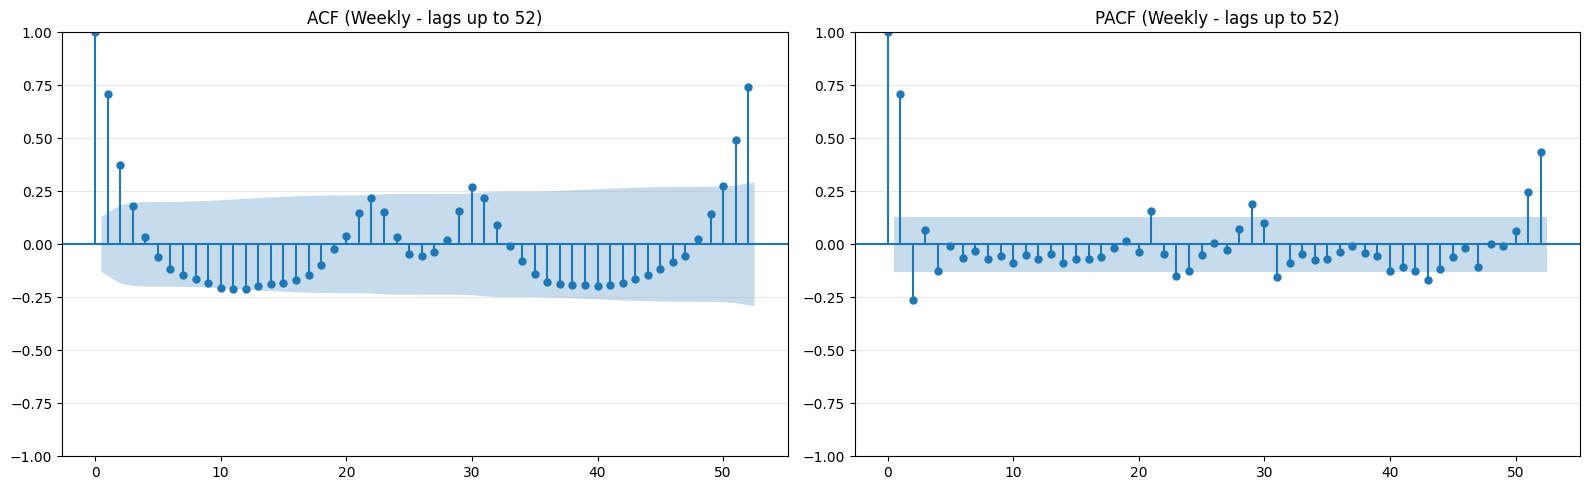

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

y = weekly_ts.fillna(0)

target_lags = 52

max_pacf_lags = max(1, min(target_lags, len(y) // 2 - 1))
max_acf_lags = target_lags

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(y, lags=max_acf_lags, ax=axes[0])
axes[0].set_title(f'ACF (Weekly - lags up to {max_acf_lags})')
axes[0].grid(alpha=0.3, axis='y')

plot_pacf(y, lags=max_pacf_lags, ax=axes[1], method='ywm')
axes[1].set_title(f'PACF (Weekly - lags up to {max_pacf_lags})')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()



1.  **Strong Annual Seasonality:** The ACF shows a "sine wave" pattern with a peak at **Lag 52**, confirming that student registrations follow a predictable yearly cycle.
2.  **Non-Stationarity:** The slow decay in the ACF plot indicates the data is non-stationary, meaning the mean and variance change over time (driven by the seasonality).
3.  **Short-term Momentum:** The PACF shows sharp spikes at **Lags 1 and 2**, suggesting that the number of registrations in a given week is strongly predicted by the activity in the two weeks prior.

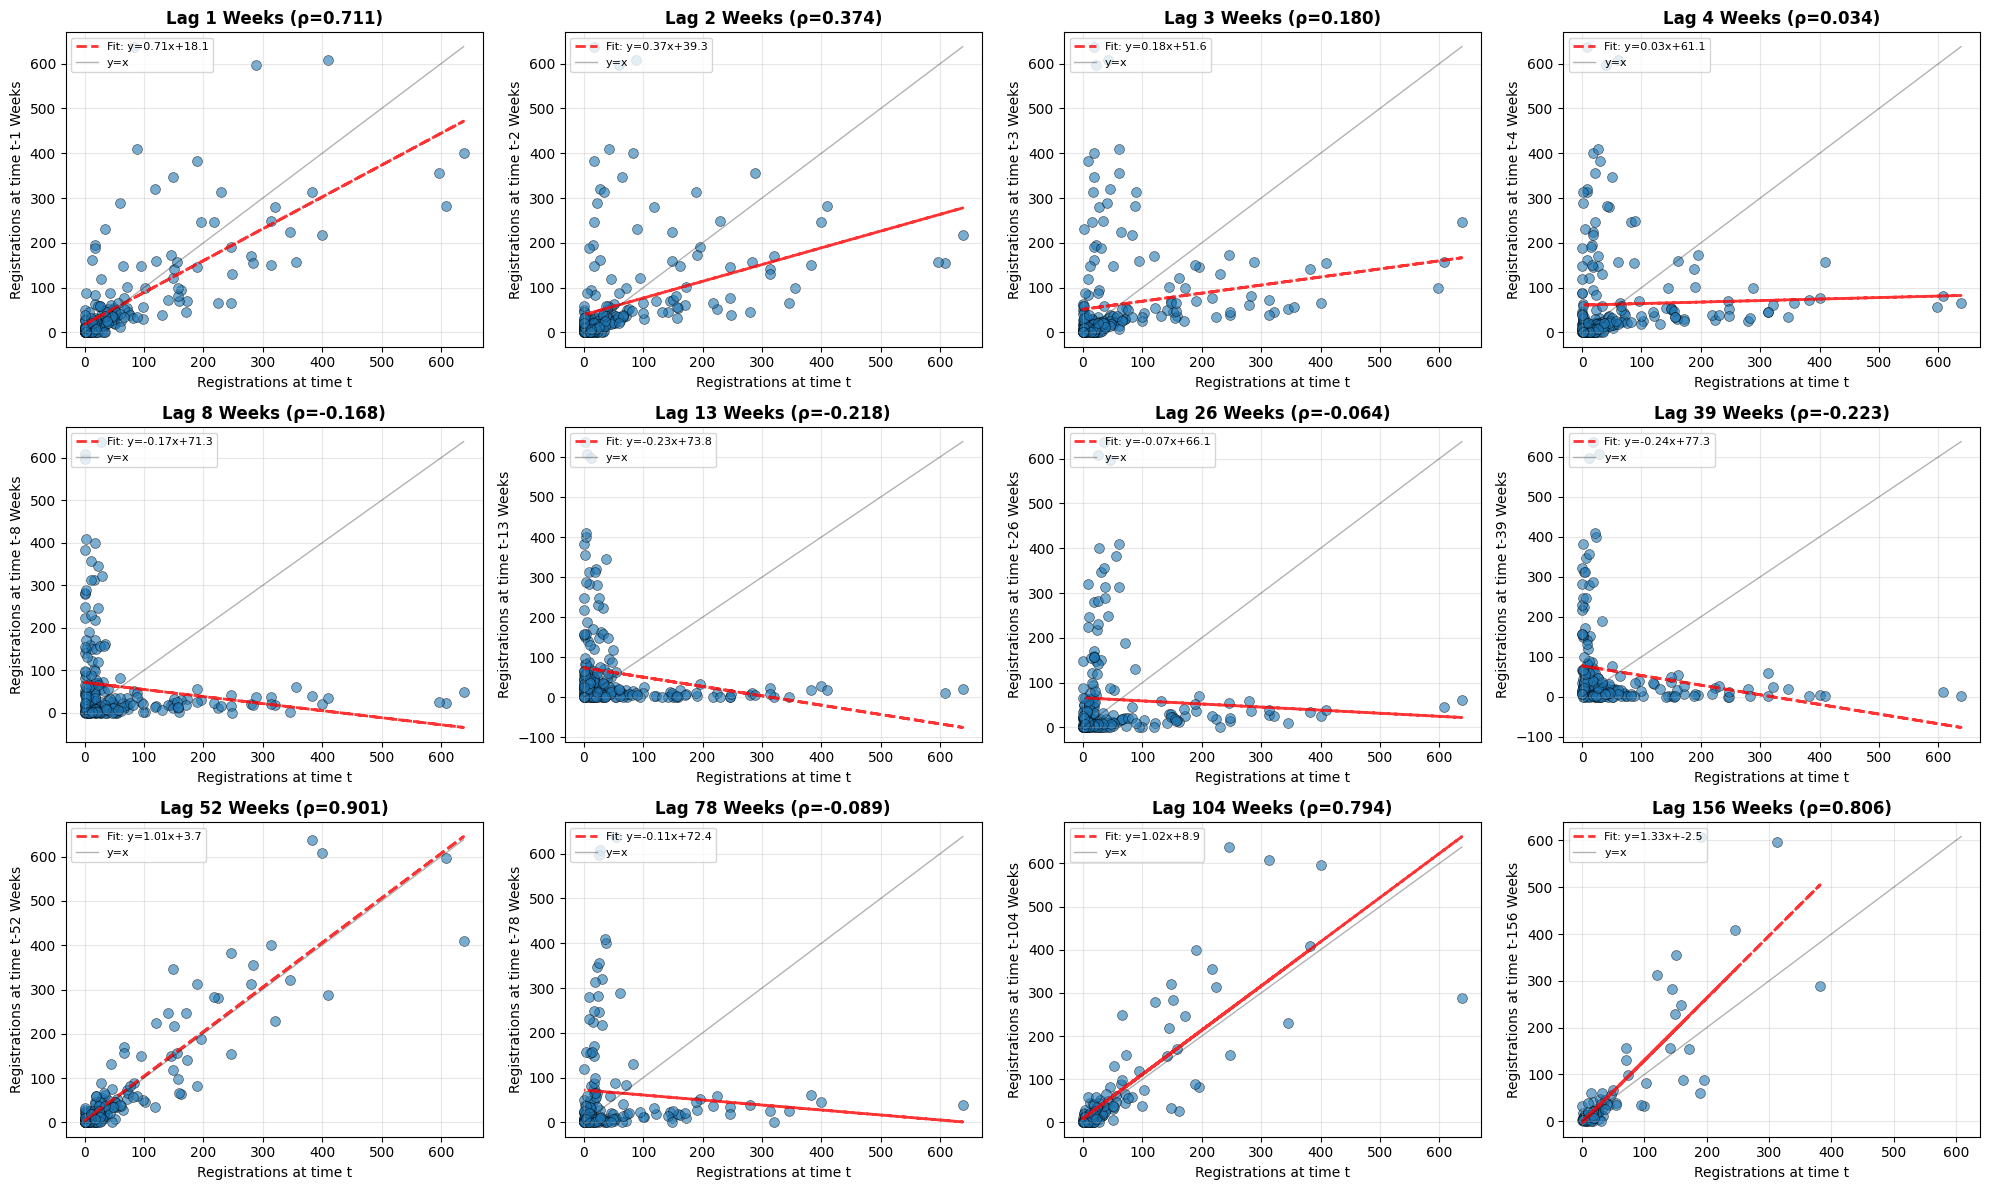

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

lags_to_plot = [1, 2, 3, 4, 8, 13, 26, 39, 52, 78, 104, 156]

for i, lag in enumerate(lags_to_plot):
    ax = axes[i]
    
    y = weekly_ts.values[lag:]
    x = weekly_ts.values[:-lag]
    
    ax.scatter(x, y, alpha=0.6, s=50, edgecolors='black', linewidths=0.5)
    
    if len(x) > 1:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        ax.plot(x, p(x), "r--", linewidth=2, alpha=0.8, label=f'Fit: y={z[0]:.2f}x+{z[1]:.1f}')
    
    corr = weekly_ts.autocorr(lag=lag)
    
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, 'k-', alpha=0.3, linewidth=1, label='y=x')
    
    ax.set_title(f'Lag {lag} Weeks (ρ={corr:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Registrations at time t')
    ax.set_ylabel(f'Registrations at time t-{lag} Weeks')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()